In [1]:
# Импорт библиотек
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Фиксируем seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Проверяем GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Устройство:", device)

Устройство: cpu


Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


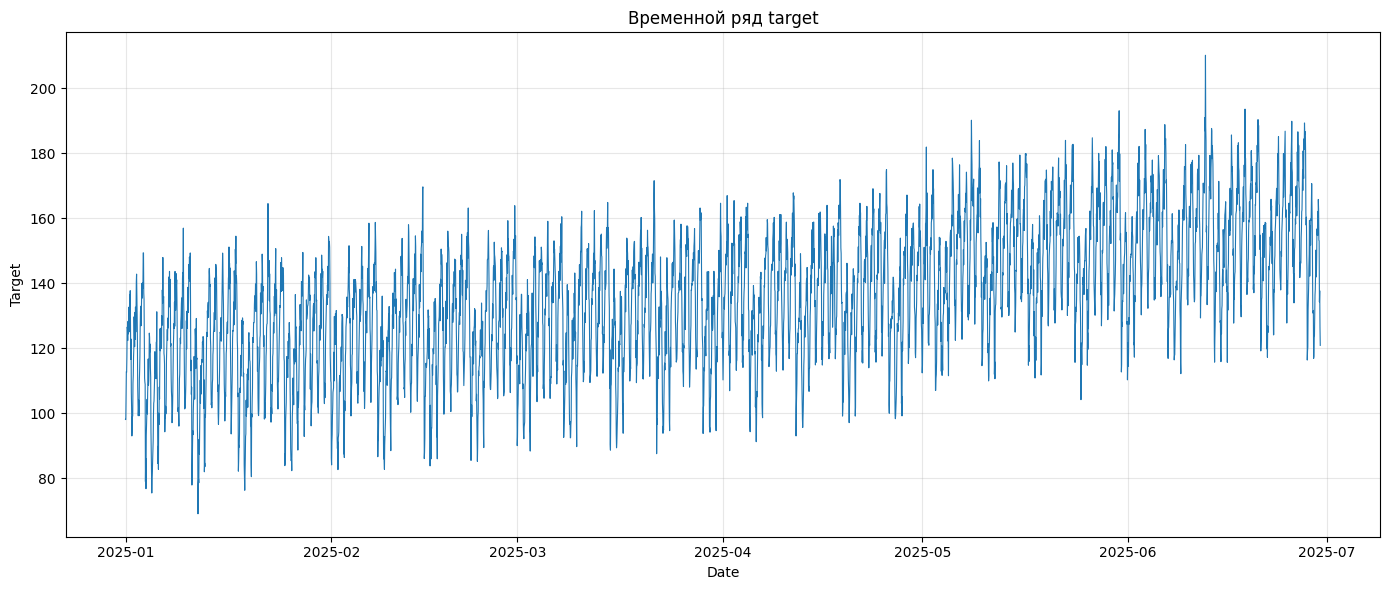

In [2]:
# Загрузка данных
df = pd.read_csv("S12-hw-dataset.csv")

# Приведение 'date' к datetime и сортировка
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Базовая информация
print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "—", df["date"].max())

print("\nПропуски по колонкам:")
print(df.isna().sum())

# График временного ряда
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["target"], linewidth=0.8)
plt.title("Временной ряд target")
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("artifacts/figures/raw_series.png", dpi=150) 
plt.show()

Тренд. Наблюдается выраженный восходящий тренд. Средний уровень ряда постепенно увеличивается примерно от 110–120 в начале периода до примерно 150–170 к концу.

Сезонность. Видны регулярные периодические колебания. Поскольку данные почасовые (4320 = 180 дней × 24 часа), колебания с высокой вероятностью связаны с суточной сезонностью.

Выбросы. Отдельные значения заметно отклоняются от основной динамики (например, резкие падения или пики), однако они не выглядят экстремальными относительно общей амплитуды.

Нестационарность. Ряд вероятно нестационарный, так как:
- присутствует тренд;
- меняется средний уровень со временем;
- присутствует сезонная структура.

Train:
2025-01-01 00:00:00 — 2025-05-06 23:00:00 | size: 3024

Validation:
2025-05-07 00:00:00 — 2025-06-02 23:00:00 | size: 648

Test:
2025-06-03 00:00:00 — 2025-06-29 23:00:00 | size: 648


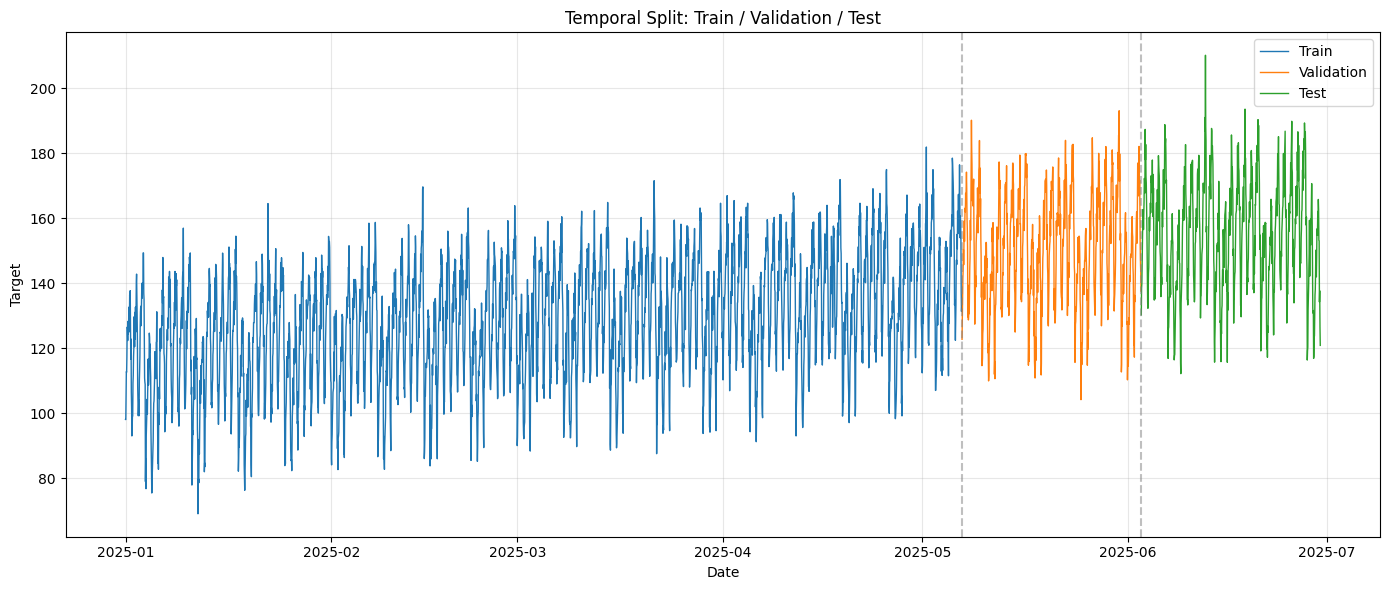

In [3]:
# Доли разбиения
train_ratio = 0.7
val_ratio = 0.15

n = len(df)

train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Temporal split
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# Границы
print("Train:")
print(train_df["date"].min(), "—", train_df["date"].max(), "| size:", len(train_df))
print("\nValidation:")
print(val_df["date"].min(), "—", val_df["date"].max(), "| size:", len(val_df))
print("\nTest:")
print(test_df["date"].min(), "—", test_df["date"].max(), "| size:", len(test_df))

# Визуализация split
plt.figure(figsize=(14, 6))

plt.plot(train_df["date"], train_df["target"], label="Train", linewidth=1)
plt.plot(val_df["date"], val_df["target"], label="Validation", linewidth=1)
plt.plot(test_df["date"], test_df["target"], label="Test", linewidth=1)

# Добавляем вертикальные линии для разделения
plt.axvline(x=train_df["date"].max(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val_df["date"].max(), color='gray', linestyle='--', alpha=0.5)

plt.title("Temporal Split: Train / Validation / Test")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()

random split (cлучайное разбиение)  перемешивает наблюдения из разных моментов времени. В результате в обучающую выборку могут попасть точки, которые находятся позже во времени, чем данные в валидации или тесте. Это приводит к утечке информации из будущего (data leakage) и делает оценку качества модели нереалистично оптимистичной. Для задач временных рядов это нарушает причинную структуру данных, поэтому используется только temporal split.

In [4]:
# Создание признаков
df_feat = df.copy()

# Lag признаки
df_feat["lag_1"] = df_feat["target"].shift(1)
df_feat["lag_7"] = df_feat["target"].shift(7)
df_feat["lag_14"] = df_feat["target"].shift(14)

# Rolling признаки (используем shift, чтобы не брать текущее значение)
df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(window=7).mean()
df_feat["rolling_std_7"] = df_feat["target"].shift(1).rolling(window=7).std()

# Календарные признаки
df_feat["day_of_week"] = df_feat["date"].dt.dayofweek
df_feat["month"] = df_feat["date"].dt.month
df_feat["hour"] = df_feat["date"].dt.hour

# Удаление строк с NaN (появились из-за lag и rolling)
df_feat = df_feat.dropna().reset_index(drop=True)

print("Признаки созданы:")
print(df_feat.columns.tolist())
print("\nРазмер после удаления NaN:", len(df_feat))

# Повторим temporal split, потому что первые строки были удалены
n = len(df_feat)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df_feat = df_feat.iloc[:train_end].copy()
val_df_feat = df_feat.iloc[train_end:val_end].copy()
test_df_feat = df_feat.iloc[val_end:].copy()

print("\nРазмеры после split:")
print("Train:", len(train_df_feat))
print("Validation:", len(val_df_feat))
print("Test:", len(test_df_feat))

Признаки созданы:
['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'hour']

Размер после удаления NaN: 4306

Размеры после split:
Train: 3014
Validation: 646
Test: 646


In [5]:
# Подготовка последовательностей фиксированной длины
window_size = 24  # 24 часа

# Берем только target для GRU
series = df["target"].values.astype("float32")

# Temporal split для ряда
n = len(series)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_series = series[:train_end]
val_series = series[train_end:val_end]
test_series = series[val_end:]

# Масштабирование по train
scaler = StandardScaler()

train_series_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
val_series_scaled = scaler.transform(val_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

print("Масштабирование выполнено (fit только на train)")
print("Train mean после scaling:", train_series_scaled.mean())
print("Train std после scaling:", train_series_scaled.std())

# Функция создания windows
def create_windows(series, window):
    X = []
    y = []
    
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    
    return np.array(X), np.array(y)

X_train_gru, y_train_gru = create_windows(train_series_scaled, window_size)
X_val_gru, y_val_gru = create_windows(val_series_scaled, window_size)
X_test_gru, y_test_gru = create_windows(test_series_scaled, window_size)

print("\nФормы данных для GRU:")
print("X_train:", X_train_gru.shape, "| y_train:", y_train_gru.shape)
print("X_val:", X_val_gru.shape, "| y_val:", y_val_gru.shape)
print("X_test:", X_test_gru.shape, "| y_test:", y_test_gru.shape)

# Dataset и DataLoader для PyTorch
class TimeSeriesDataset(Dataset):    
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, Window, 1)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_dataset = TimeSeriesDataset(X_train_gru, y_train_gru)
val_dataset = TimeSeriesDataset(X_val_gru, y_val_gru)
test_dataset = TimeSeriesDataset(X_test_gru, y_test_gru)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("\nDataLoader создан:")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Масштабирование выполнено (fit только на train)
Train mean после scaling: 0.0
Train std после scaling: 1.0

Формы данных для GRU:
X_train: (3000, 24) | y_train: (3000,)
X_val: (624, 24) | y_val: (624,)
X_test: (624, 24) | y_test: (624,)

DataLoader создан:
Train batches: 47
Val batches: 10
Test batches: 10


In [6]:
# Модель GRU модель для прогнозирования временных рядов
class GRUModel(nn.Module): 
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.gru(x)  # out: (batch, window, hidden_size)
        out = out[:, -1, :]  # Берем последний временной шаг
        out = self.fc(out)  # (batch, 1)
        
        return out.squeeze()

# Функция обучения
def train_epoch(model, loader, optimizer, criterion, device):    
    model.train()
    total_loss = 0
    
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X.size(0)
    
    return total_loss / len(loader.dataset)

# Функция оценки
def evaluate(model, loader, criterion, device):    
    model.eval()
    total_loss = 0
    preds = []
    targets = []
    
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            
            pred = model(X)
            loss = criterion(pred, y)
            total_loss += loss.item() * X.size(0)
            
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    
    mse = ((preds - targets) ** 2).mean()
    mae = np.abs(preds - targets).mean()
    
    return total_loss / len(loader.dataset), mse, mae

# Функция для расчета всех метрик
def calculate_metrics(y_true, y_pred):    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE с защитой от деления на ноль
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return mae, rmse, mape


In [ ]:
# Создаем директорию для доп файлов
os.makedirs("artifacts/figures", exist_ok=True)

# Список для хранения результатов
runs_data = []

# Функция вывода информации об эксперименте
def log_experiment(exp_id, model_name, val_true, val_pred,
                   test_true, test_pred, window_size=None,
                   features="", optimizer="", lr=0, epochs=0, notes=""):   
    
    val_mae, val_rmse, val_mape = calculate_metrics(val_true, val_pred)
    test_mae, test_rmse, test_mape = calculate_metrics(test_true, test_pred)
    
    run = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": SEED,
        "split_summary": "70/15/15 (Temporal)",
        "window_size": window_size if window_size else "N/A",
        "horizon": 1,
        "model_summary": model_name,
        "features_summary": features,
        "scaler": "StandardScaler" if 'scaler' in dir() else "None",
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_mae": val_mae,
        "best_val_rmse": val_rmse,
        "best_val_mape": val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes
    }
    
    runs_data.append(run)
    print(f"[{exp_id}] Val MAE: {val_mae:.4f}, Test MAE: {test_mae:.4f}")
    
    return val_mae

In [8]:
# ЭКСПЕРИМЕНТ B1: NAIVE-LAST
def naive_last_forecast(train, val, test):
    # Наивный baseline: прогноз = последнее известное значение y_t = y_{t-1}
    val_pred = np.roll(val, 1)
    val_pred[0] = train[-1]  # Первое значение берем из конца train
    
    test_pred = np.roll(test, 1)
    test_pred[0] = val[-1]  # Первое значение берем из конца val
    
    return val_pred, test_pred

val_pred_b1, test_pred_b1 = naive_last_forecast(train_series, val_series, test_series)

log_experiment(
    exp_id="B1",
    model_name="naive-last",
    val_true=val_series,
    val_pred=val_pred_b1,
    test_true=test_series,
    test_pred=test_pred_b1,
    notes="Baseline: y_t = y_{t-1}"
)

[B1] Val MAE: 6.4448, Test MAE: 6.3424


6.444814

In [9]:
# ЭКСПЕРИМЕНТ B2: MOVING-AVERAGE
def moving_average_forecast(train, val, test, window=7):
    # Baseline на основе скользящего среднего
    val_pred = np.zeros_like(val)
    for i in range(len(val)):
        if i == 0:
            # Первое предсказание: среднее последних window значений train
            history = train[-window:]
            val_pred[i] = np.mean(history)
        else:
            # Последующие: среднее последних window значений (train + val до текущего)
            context = list(train[-window:]) + list(val[:i])
            val_pred[i] = np.mean(context[-window:])
    
    test_pred = np.zeros_like(test)
    for i in range(len(test)):
        if i == 0:
            # Первое предсказание: среднее последних window значений val
            history = val[-window:]
            test_pred[i] = np.mean(history)
        else:
            # Последующие: среднее последних window значений (val + test до текущего)
            context = list(val[-window:]) + list(test[:i])
            test_pred[i] = np.mean(context[-window:])
    
    return val_pred, test_pred

window_ma = 7
val_pred_b2, test_pred_b2 = moving_average_forecast(train_series, val_series, test_series, window_ma)

log_experiment(
    exp_id="B2",
    model_name=f"Moving Average (w={window_ma})",
    val_true=val_series,
    val_pred=val_pred_b2,
    test_true=test_series,
    test_pred=test_pred_b2,
    window_size=window_ma,
    notes=f"Sliding window mean size {window_ma}"
)

[B2] Val MAE: 12.7020, Test MAE: 12.7403


12.702011

In [10]:
# ЭКСПЕРИМЕНТ B3: RIDGE-LAG-FEATURES

# Подготовка признаков для Ridge 
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "month",
    "hour"
]

X_ridge = df_feat[feature_cols].values
y_ridge = df_feat["target"].values

# Temporal split
n = len(df_feat)
tr_idx = int(n * 0.7)
val_idx = int(n * 0.85)

X_train_ridge = X_ridge[:tr_idx]
X_val_ridge = X_ridge[tr_idx:val_idx]
X_test_ridge = X_ridge[val_idx:]

y_train_ridge = y_ridge[:tr_idx]
y_val_ridge = y_ridge[tr_idx:val_idx]
y_test_ridge = y_ridge[val_idx:]

# Масштабирование
scaler_ridge = StandardScaler()
X_train_ridge_sc = scaler_ridge.fit_transform(X_train_ridge)
X_val_ridge_sc = scaler_ridge.transform(X_val_ridge)
X_test_ridge_sc = scaler_ridge.transform(X_test_ridge)

# Обучение Ridge
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_ridge_sc, y_train_ridge)

# Предсказания
val_pred_b3 = model_ridge.predict(X_val_ridge_sc)
test_pred_b3 = model_ridge.predict(X_test_ridge_sc)

log_experiment(
    exp_id="B3",
    model_name="Ridge Regression",
    val_true=y_val_ridge,
    val_pred=val_pred_b3,
    test_true=y_test_ridge,
    test_pred=test_pred_b3,
    window_size=24,
    features="Lags(1,7,14), RollMean/Std(7), Time features",
    optimizer="Closed-form",
    notes="Linear model with engineered features"
)

[B3] Val MAE: 5.9909, Test MAE: 5.6373


5.9908782764832225

In [11]:
# ЭКСПЕРИМЕНТ R1: GRU-FORECAST

# Параметры
hidden_size = 64
lr_gru = 1e-3
epochs_gru = 20

# Модель
model_gru = GRUModel(input_size=1, hidden_size=hidden_size, num_layers=1).to(device)

optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=lr_gru)
criterion = nn.MSELoss()

# История обучения
history_loss = []
history_mae = []

best_val_loss = float('inf')


for epoch in range(epochs_gru):
    # Обучение
    train_loss = train_epoch(model_gru, train_loader, optimizer_gru, criterion, device)
    
    # Оценка на validation
    val_loss, val_mse, val_mae = evaluate(model_gru, val_loader, criterion, device)
    
    history_loss.append(train_loss)
    history_mae.append(val_mae)
    
    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_gru.state_dict(), "artifacts/best_gru.pt")
        
        # Сохраняем конфиг
        config = {
            "window_size": window_size,
            "hidden_size": hidden_size,
            "batch_size": batch_size,
            "learning_rate": lr_gru,
            "epochs": epochs_gru,
            "seed": SEED,
            "architecture": "GRU(1->64->1)",
            "scaler": "StandardScaler"
        }
        with open("artifacts/best_gru_config.json", "w") as f:
            json.dump(config, f, indent=4)
    
    print(f"Epoch {epoch+1}/{epochs_gru} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"val_mae={val_mae:.4f}")
        
# Загрузка лучшей модели
model_gru.load_state_dict(torch.load("artifacts/best_gru.pt"))
model_gru.eval()

# Оценка на test
test_loss, test_mse, test_mae_scaled = evaluate(model_gru, test_loader, criterion, device)

# Получаем предсказания в оригинальном масштабе
val_preds_scaled = []
val_targets_scaled = []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        pred = model_gru(X)
        val_preds_scaled.append(pred.cpu().numpy())
        val_targets_scaled.append(y.numpy())

test_preds_scaled = []
test_targets_scaled = []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model_gru(X)
        test_preds_scaled.append(pred.cpu().numpy())
        test_targets_scaled.append(y.numpy())

val_preds_scaled = np.concatenate(val_preds_scaled)
val_targets_scaled = np.concatenate(val_targets_scaled)
test_preds_scaled = np.concatenate(test_preds_scaled)
test_targets_scaled = np.concatenate(test_targets_scaled)

# Обратное масштабирование
val_pred_r1 = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
val_true_r1 = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).flatten()
test_pred_r1 = scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()
test_true_r1 = scaler.inverse_transform(test_targets_scaled.reshape(-1, 1)).flatten()

log_experiment(
    exp_id="R1",
    model_name="GRU Neural Network",
    val_true=val_true_r1,
    val_pred=val_pred_r1,
    test_true=test_true_r1,
    test_pred=test_pred_r1,
    window_size=window_size,
    features="Raw scaled sequence",
    optimizer="Adam",
    lr=lr_gru,
    epochs=epochs_gru,
    notes=f"Hidden size {hidden_size}, Best Val Loss {best_val_loss:.4f}"
)

Epoch 1/20 | train_loss=0.7335 | val_loss=0.5948 | val_mae=0.6585
Epoch 2/20 | train_loss=0.2359 | val_loss=0.2273 | val_mae=0.3805
Epoch 3/20 | train_loss=0.1762 | val_loss=0.2484 | val_mae=0.3987
Epoch 4/20 | train_loss=0.1651 | val_loss=0.2048 | val_mae=0.3617
Epoch 5/20 | train_loss=0.1559 | val_loss=0.2416 | val_mae=0.3986
Epoch 6/20 | train_loss=0.1521 | val_loss=0.1856 | val_mae=0.3453
Epoch 7/20 | train_loss=0.1481 | val_loss=0.2247 | val_mae=0.3811
Epoch 8/20 | train_loss=0.1455 | val_loss=0.2473 | val_mae=0.3988
Epoch 9/20 | train_loss=0.1427 | val_loss=0.1833 | val_mae=0.3413
Epoch 10/20 | train_loss=0.1253 | val_loss=0.1808 | val_mae=0.3349
Epoch 11/20 | train_loss=0.1121 | val_loss=0.1750 | val_mae=0.3296
Epoch 12/20 | train_loss=0.1087 | val_loss=0.1920 | val_mae=0.3431
Epoch 13/20 | train_loss=0.1067 | val_loss=0.1625 | val_mae=0.3191
Epoch 14/20 | train_loss=0.1057 | val_loss=0.1766 | val_mae=0.3283
Epoch 15/20 | train_loss=0.1036 | val_loss=0.1793 | val_mae=0.3298
Epoc

5.5192156

In [12]:
# Сохранение таблицы результатов
df_runs = pd.DataFrame(runs_data)
df_runs.to_csv("artifacts/runs.csv", index=False)
print(df_runs[['experiment_id', 'best_val_mae', 'test_mae']].sort_values('best_val_mae'))

# Выбор лучшей модели по validation MAE
best_row = df_runs.loc[df_runs['best_val_mae'].idxmin()]
best_exp_id = best_row['experiment_id']
print(f"\nЛучшая модель по Validation MAE: {best_exp_id}")

  experiment_id  best_val_mae   test_mae
3            R1      5.519216   6.321949
2            B3      5.990878   5.637283
0            B1      6.444814   6.342438
1            B2     12.702011  12.740308

Лучшая модель по Validation MAE: R1


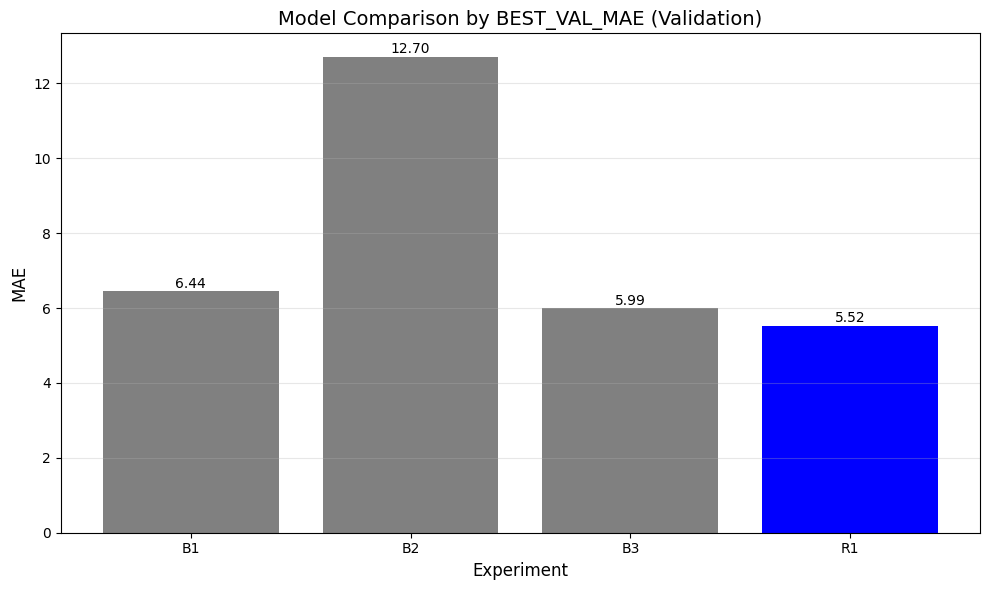

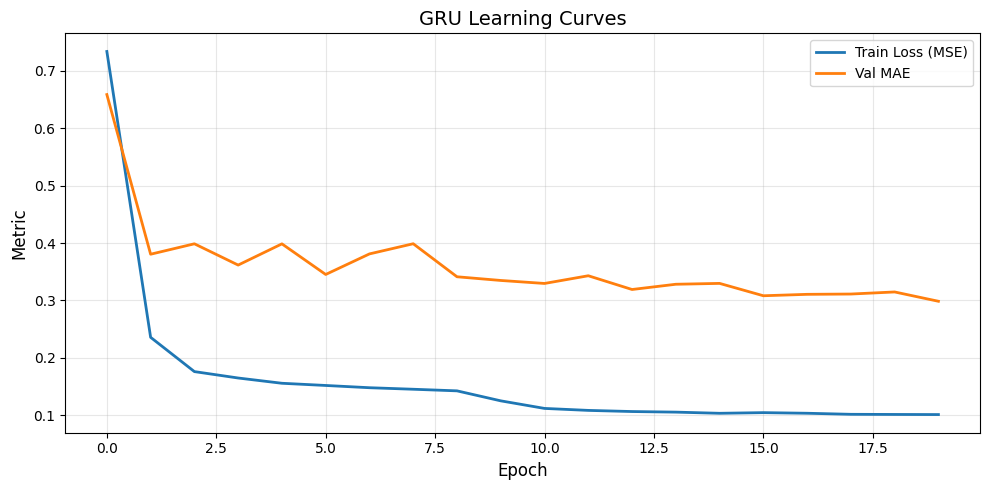

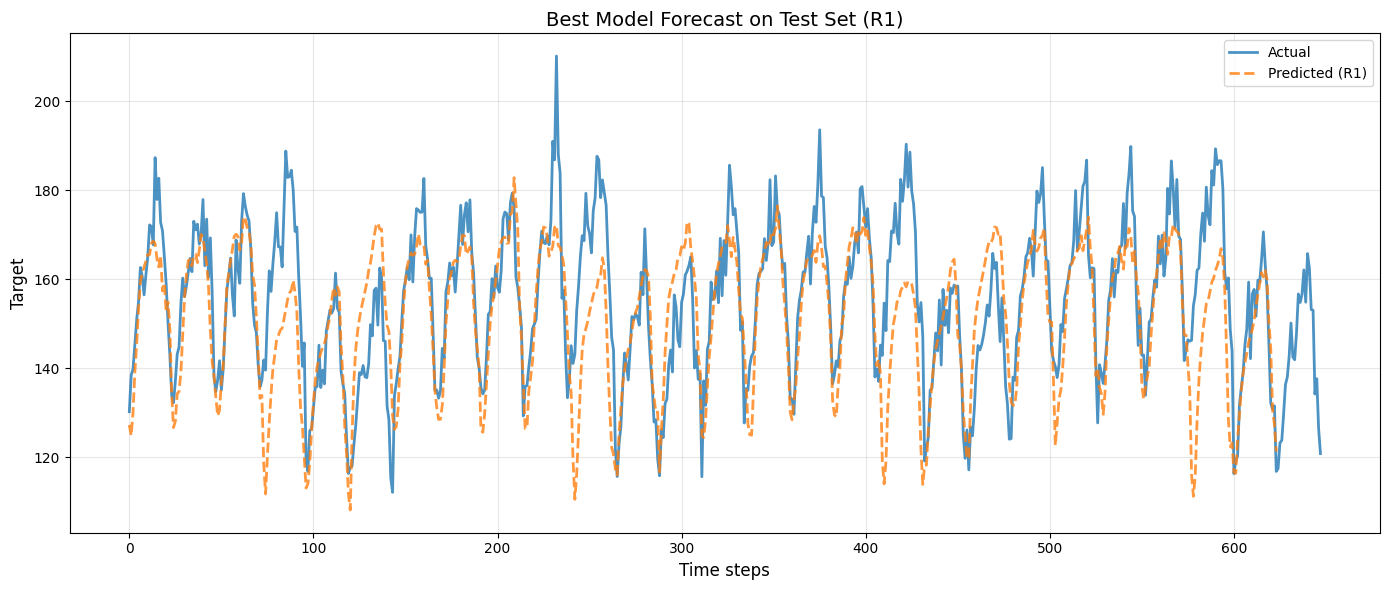

Все графики сохранены в artifacts/figures/


In [13]:
# График series_split.png (уже сохранен ранее)

# График baselines_compare.png
plt.figure(figsize=(10, 6))
metrics_to_plot = 'best_val_mae'
colors = ['gray', 'gray', 'gray', 'blue']
plt.bar(df_runs['experiment_id'], df_runs[metrics_to_plot], color=colors)
plt.title(f'Model Comparison by {metrics_to_plot.upper()} (Validation)', fontsize=14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Experiment', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Добавим значения на столбцы
for i, v in enumerate(df_runs[metrics_to_plot]):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# График gru_learning_curves.png
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Train Loss (MSE)', linewidth=2)
plt.plot(history_mae, label='Val MAE', linewidth=2)
plt.title('GRU Learning Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# График best_forecast_test.png
if best_exp_id == 'B1':
    y_pred_best = test_pred_b1
elif best_exp_id == 'B2':
    y_pred_best = test_pred_b2
elif best_exp_id == 'B3':
    y_pred_best = test_pred_b3
else:  # R1
    y_pred_best = test_pred_r1

y_true_best = test_series

plt.figure(figsize=(14, 6))
plt.plot(y_true_best, label='Actual', linewidth=2, alpha=0.8)
plt.plot(y_pred_best, label=f'Predicted ({best_exp_id})', linestyle='--', linewidth=2, alpha=0.8)
plt.title(f'Best Model Forecast on Test Set ({best_exp_id})', fontsize=14)
plt.xlabel('Time steps', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()


print("Все графики сохранены в artifacts/figures/")